### Weatherlens India Clustering model 

In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
import os
warnings.filterwarnings("ignore")

In [3]:
df=pd.read_csv("C:/Internships/projects/WeatherLens India/clean_weather.csv")
df.head(3)

,city,date,temperature_2m_max,temperature_2m_min,apparent_temperature_max,apparent_temperature_min,rain_sum,wind_speed_10m_max,rain_tomorrow,weather_condition,year,month,day,season,temp_range
0,Delhi,01-01-2000,19.9,7.4,19.2,5.8,0.0,10.9,0,Clear,2000,1,1,Winter,12.5
1,Delhi,02-01-2000,20.0,5.5,18.9,3.4,0.0,9.5,0,Overcast,2000,1,2,Winter,14.5
2,Delhi,03-01-2000,20.1,6.3,18.2,4.3,0.0,10.0,0,Clear,2000,1,3,Winter,13.8


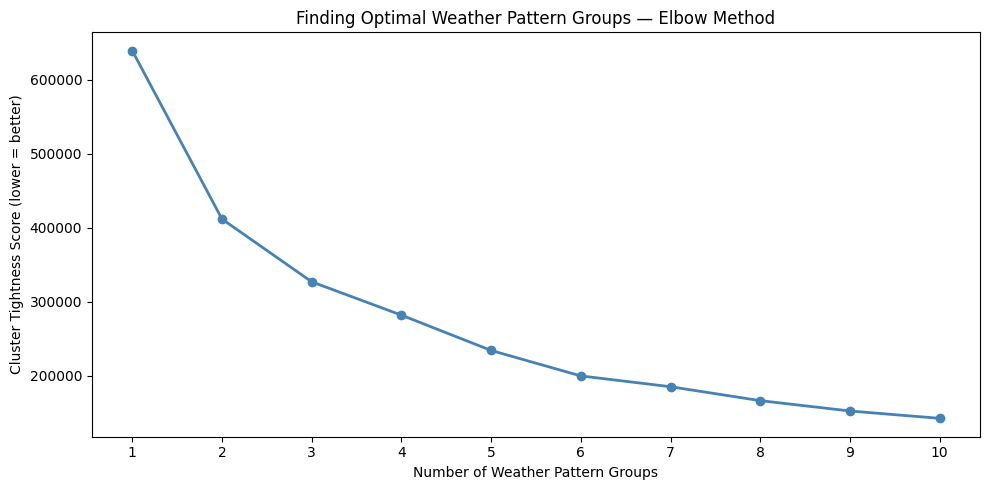

In [6]:
#kmeans clustering
cluster_features = ['temperature_2m_max', 'temperature_2m_min',
                    'apparent_temperature_max', 'apparent_temperature_min',
                    'rain_sum', 'wind_speed_10m_max', 'temp_range']

X = df[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#elbow method to find optimal number of clusters
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_) 

plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
plt.title('Finding Optimal Weather Pattern Groups — Elbow Method')
plt.xlabel('Number of Weather Pattern Groups')
plt.ylabel('Cluster Tightness Score (lower = better)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

## K-Means Clustering — Observations
### Elbow Method Finding:

The Elbow Method was applied by running K-Means for K=1 through K=10 and measuring the cluster tightness score (inertia) at each step. The curve showed a significant drop from K=1 to K=2 (230k improvement) and a notable drop from K=2 to K=3 (85k improvement). Beyond K=3, improvements became gradually smaller, indicating diminishing returns.

### Why K=4 was chosen:
While the mathematical elbow appears around K=3, K=4 was selected as the optimal number of clusters by combining statistical evidence with domain knowledge. Indian weather cannot be realistically summarized in just 3 patterns — the dataset covers 10 cities across diverse climate zones ranging from semi-arid Rajasthan to coastal Mumbai. K=4 captures this diversity while keeping clusters meaningful and interpretable.

### Expected Weather Pattern Groups:
With K=4 we expect the clusters to naturally represent:<br>
Heavy monsoon days (high rainfall, low temp range)<br>
Dry summer days (high temperature, zero rainfall)<br>
Mild transition days (moderate temp, light rain)<br>
Cold winter days (low temperature, zero rainfall)

### Impact on ML Model:

The cluster label assigned to each day will be added as a new feature column weather_cluster in the dataset. This engineered feature from unsupervised learning will enrich the supervised Random Forest model, helping it understand broader weather context beyond individual measurements.

In [7]:
# Final K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['weather_cluster'] = kmeans.fit_predict(X_scaled)

# See how many days fell in each cluster
print(df['weather_cluster'].value_counts())

weather_cluster
2    30705
1    28164
3    19335
0    13116
Name: count, dtype: int64


In [8]:
# See average values for each cluster
cluster_summary = df.groupby('weather_cluster')[
    ['temperature_2m_max', 'temperature_2m_min', 
     'rain_sum', 'wind_speed_10m_max', 
     'temp_range']].mean().round(2)

print(cluster_summary)

                 temperature_2m_max  temperature_2m_min  rain_sum  \
weather_cluster                                                     
0                             24.35               11.61      0.28   
1                             31.11               18.96      0.37   
2                             35.25               25.83      1.42   
3                             28.14               23.27     11.63   

                 wind_speed_10m_max  temp_range  
weather_cluster                                  
0                             12.47       12.74  
1                             13.05       12.15  
2                             16.76        9.41  
3                             19.23        4.87  


In [9]:
cluster_names = {
    0: 'Cold Winter',
    1: 'Mild Transition',
    2: 'Dry Summer',
    3: 'Heavy Monsoon'
}

df['weather_pattern'] = df['weather_cluster'].map(cluster_names)
print(df['weather_pattern'].value_counts())

weather_pattern
Dry Summer         30705
Mild Transition    28164
Heavy Monsoon      19335
Cold Winter        13116
Name: count, dtype: int64


In [10]:
from sklearn.decomposition import PCA

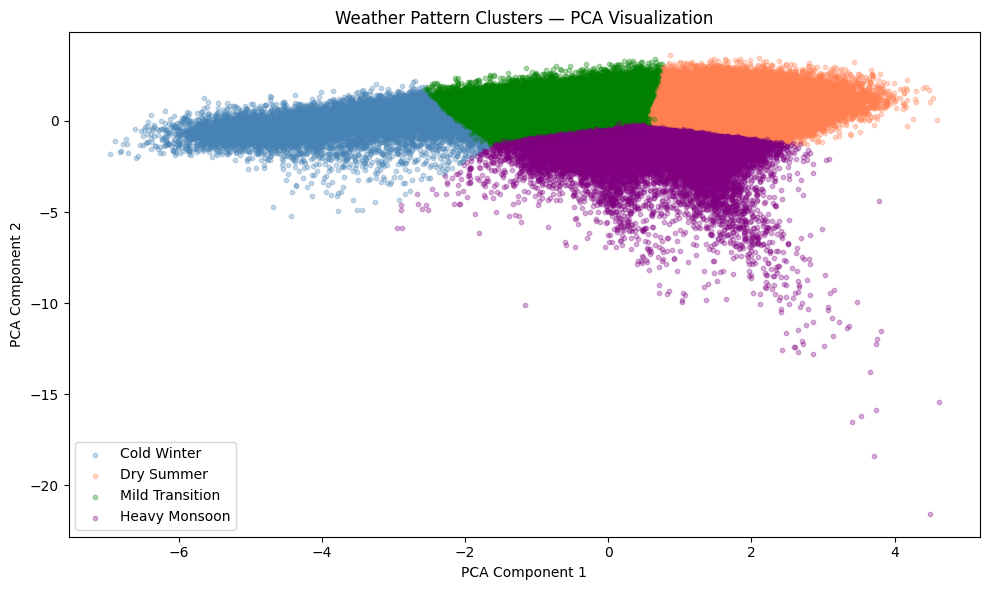

In [12]:
# Compress 7 features into 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Plot
plt.figure(figsize=(10, 6))
colors = {'Cold Winter':'steelblue', 'Dry Summer':'coral', 
          'Mild Transition':'green', 'Heavy Monsoon':'purple'}

for pattern, color in colors.items():
    mask = df['weather_pattern'] == pattern
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=color, label=pattern, alpha=0.3, s=10)

plt.title('Weather Pattern Clusters — PCA Visualization')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend()
plt.tight_layout()
plt.show()

## PCA
Principal Component Analysis (PCA) compressed 7 weather features (temperature, rainfall, wind speed, temp range etc.) into just 2 dimensions so we can visually plot and understand the clusters on a simple 2D chart.

### What the chart tells us:
🔵 Cold Winter (far left):<br>
- Sits completely separate from all other clusters on the left side — confirming that cold winter days are the most distinctly different weather pattern in India. 
- Low temperatures and large temp ranges make these days uniquely identifiable.

🟠 Dry Summer (far right):<br>
- Clearly positioned on the right side — well separated from Cold Winter.
- High temperatures and near zero rainfall make summer days a distinct and well defined cluster.

🟢 Mild Transition (top middle):<br>
- Sits between Cold Winter and Dry Summer — exactly where you'd expect transition weather to be.
- These are the pre-winter and post-monsoon days that carry characteristics of both neighbouring seasons.

🟣 Heavy Monsoon (bottom middle):<br>
- The most spread out cluster — stretching far downward toward -22 on the Y axis. 
- The core monsoon days sit in the middle while the scattered purple dots represent extreme rainfall events like Mumbai floods and Kolkata storms. 
- These outlier days are so different from typical weather that PCA pushes them far from the main cluster

In [4]:
df.to_csv('clean_weather.csv', index=False)
print("Dataset updated with cluster labels!")
print(df.columns.tolist())

Dataset updated with cluster labels!
['city', 'date', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'rain_sum', 'wind_speed_10m_max', 'rain_tomorrow', 'weather_condition', 'year', 'month', 'day', 'season', 'temp_range']
